# 05 — Integration: Full Patch

Combines parameters, LFO, wavetable oscillator, and noise into a simple subtractive patch. Builds incrementally towards a playable note.

**Signal chain:**
```
NoiseOsc ──┐
            ├─ mix ─► WavetableOsc (morph LFO) ─► amplitude env ─► output
WtOsc    ──┘
                ↑
            vibrato LFO → frequency
```

**Sections:**
1. Vibrato: LFO → frequency parameter
2. Tremolo: LFO → amplitude parameter
3. Auto-morph: LFO → morph_position
4. Noise + oscillator mix
5. Full patch — note with attack/decay envelope approximation
6. Interactive synth patch explorer

In [15]:
import caspy as cp
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Audio

SR = 44100

# Shared wavetable bank
bank4 = cp.wavetable.WaveTableBank4()
import math
bank4[0].fill_sine()
bank4[1].fill_saw()
bank4[2].fill_triangle()
bank4[3].fill_with(lambda t: sum(math.sin(2*math.pi*k*t)/k for k in range(1,20,2)) * 4/math.pi)

print('caspy loaded, banks ready')

caspy loaded, banks ready


## 1. Vibrato: LFO → frequency

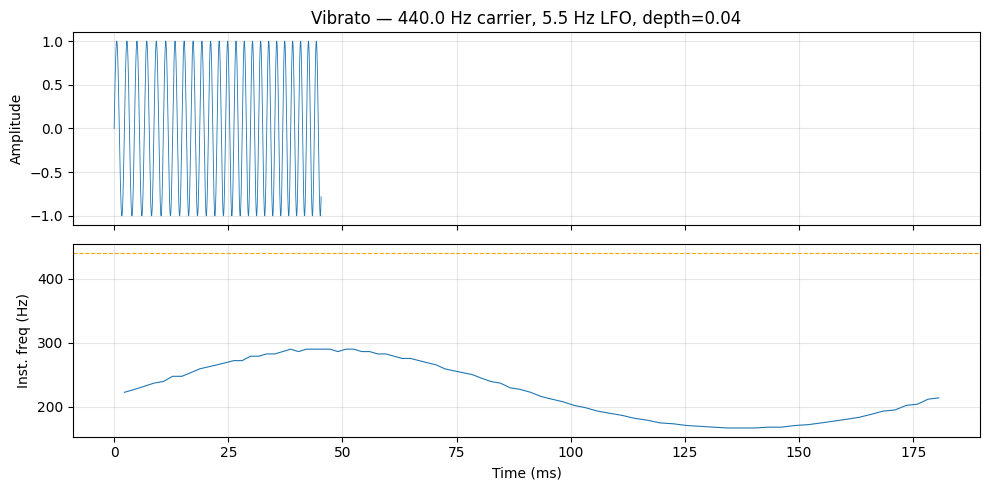

In [16]:
n = SR  # 1 s
base_freq = 440.0
vibrato_depth = 0.04   # ±4% normalised range
vibrato_rate  = 5.5    # Hz

osc = cp.wavetable.WavetableOscillator4(bank4, float(SR), base_freq)
osc.set_morph_position(0.0)  # sine

vibrato = cp.lfo.LFO(float(SR), vibrato_rate, cp.lfo.LfoShape.Sine)

buf = np.empty(n, dtype=np.float32)
for i in range(n):
    mod = vibrato.render_sample() * vibrato_depth
    osc.frequency.clear_modulation()
    osc.frequency.add_modulation(mod)
    buf[i] = osc.render_sample()

t_ms = np.arange(n) / SR * 1000
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t_ms[:2000], buf[:2000], linewidth=0.6)
axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'Vibrato — {base_freq} Hz carrier, {vibrato_rate} Hz LFO, depth={vibrato_depth}')
axes[0].grid(True, alpha=0.3)

# Show instantaneous frequency via zero-crossing period
zc = np.where(np.diff(np.sign(buf[:8000])))[0]
if len(zc) > 2:
    periods_s = np.diff(zc[::2]) / SR  # half-periods via every-other ZC
    inst_freq  = 1.0 / (periods_s * 2)
    axes[1].plot(zc[::2][1:] / SR * 1000, inst_freq, linewidth=0.8)
    axes[1].axhline(base_freq, color='orange', linestyle='--', linewidth=0.8)
    axes[1].set_ylabel('Inst. freq (Hz)')
    axes[1].set_xlabel('Time (ms)')
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
display(Audio(buf * 0.5, rate=SR, normalize=False))

## 2. Tremolo: LFO → amplitude

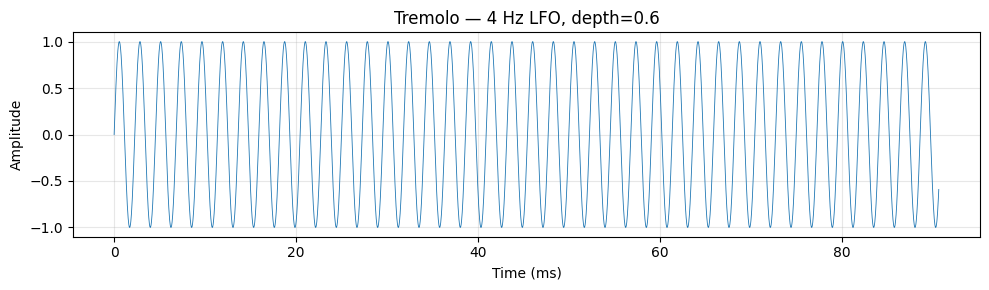

In [17]:
osc2     = cp.wavetable.WavetableOscillator4(bank4, float(SR), 440.0)
tremolo  = cp.lfo.LFO(float(SR), 4.0, cp.lfo.LfoShape.Sine, cp.lfo.LfoOutputMode.Unipolar)
depth_t  = 0.6  # modulation depth

n = SR
buf_t = np.empty(n, dtype=np.float32)
for i in range(n):
    mod = (tremolo.render_sample() - 0.5) * depth_t  # centre around 0
    osc2.amplitude.clear_modulation()
    osc2.amplitude.add_modulation(mod)
    buf_t[i] = osc2.render_sample()

t_ms = np.arange(n) / SR * 1000
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t_ms[:4000], buf_t[:4000], linewidth=0.6)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude')
ax.set_title(f'Tremolo — 4 Hz LFO, depth={depth_t}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
display(Audio(buf_t * 0.5, rate=SR, normalize=False))

## 3. Auto-morph: LFO → morph_position

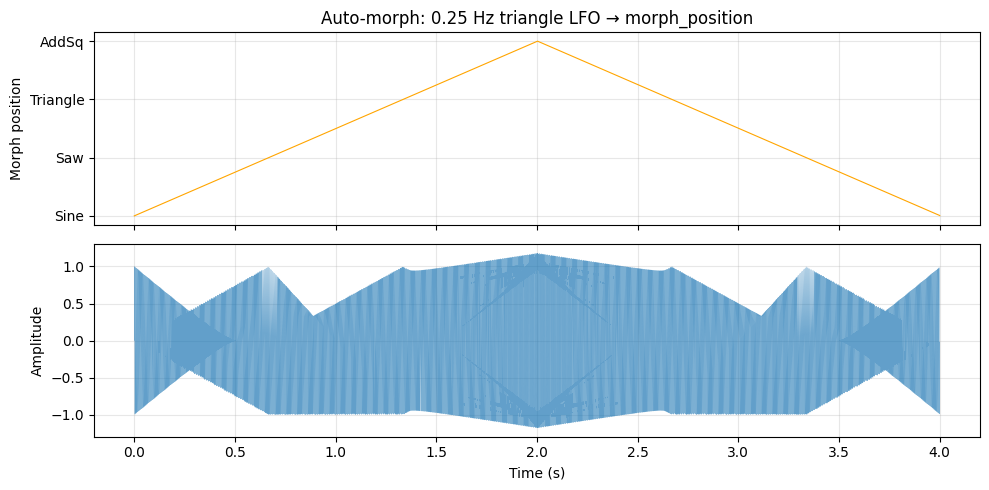

In [18]:
# LFO sweeps morph from 0 (sine) to 3 (additive square) and back
osc3      = cp.wavetable.WavetableOscillator4(bank4, float(SR), 220.0)
morph_lfo = cp.lfo.LFO(float(SR), 0.25, cp.lfo.LfoShape.Triangle, cp.lfo.LfoOutputMode.Unipolar)

n = SR * 4
buf_m = np.empty(n, dtype=np.float32)
morph_trace = np.empty(n)

for i in range(n):
    morph_val = morph_lfo.render_sample() * 3.0  # map [0,1] → [0,3]
    morph_trace[i] = morph_val
    osc3.morph_position.clear_modulation()
    osc3.morph_position.add_modulation((morph_val / 3.0) - osc3.morph_position.value_normalised())
    buf_m[i] = osc3.render_sample()

t = np.arange(n) / SR
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t, morph_trace, linewidth=0.8, color='orange')
axes[0].set_ylabel('Morph position')
axes[0].set_yticks([0, 1, 2, 3])
axes[0].set_yticklabels(['Sine', 'Saw', 'Triangle', 'AddSq'])
axes[0].set_title('Auto-morph: 0.25 Hz triangle LFO → morph_position')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, buf_m, linewidth=0.3, alpha=0.7)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
display(Audio(buf_m * 0.4, rate=SR, normalize=False))

## 4. Noise + oscillator mix

In [19]:
osc4  = cp.wavetable.WavetableOscillator4(bank4, float(SR), 440.0)
noise = cp.noise.NoiseOscillatorWhite(float(SR))

n           = SR
noise_level = 0.1   # mix ratio

buf_mix = np.empty(n, dtype=np.float32)
for i in range(n):
    osc_s   = osc4.render_sample()
    noise_s = noise.render_sample()
    buf_mix[i] = (1 - noise_level) * osc_s + noise_level * noise_s

print(f'Mix: {100*(1-noise_level):.0f}% oscillator + {100*noise_level:.0f}% noise')
display(Audio(buf_mix * 0.5, rate=SR, normalize=False))

Mix: 90% oscillator + 10% noise


## 5. Full patch: attack/decay envelope

Simple linear AD envelope applied to amplitude, vibrato fades in with a delay.

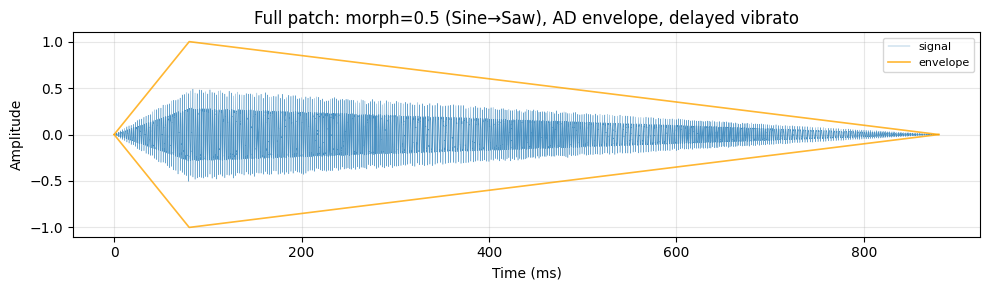

In [20]:
def render_note(freq, morph_pos, attack_ms, decay_ms, vibrato_rate, vibrato_depth,
                noise_mix=0.02, sr=SR):
    total_ms = attack_ms + decay_ms
    n        = int(sr * total_ms / 1000)
    attack_n = int(sr * attack_ms / 1000)
    decay_n  = n - attack_n

    # Envelope
    env = np.empty(n)
    env[:attack_n] = np.linspace(0, 1, attack_n)
    env[attack_n:] = np.linspace(1, 0, decay_n)

    # Vibrato delay: fades in after 20% of note
    vib_delay = int(n * 0.2)
    vib_scale = np.zeros(n)
    fade_len  = min(int(n * 0.15), n - vib_delay)
    if fade_len > 0:
        vib_scale[vib_delay:vib_delay + fade_len] = np.linspace(0, 1, fade_len)
        vib_scale[vib_delay + fade_len:]           = 1.0

    osc5    = cp.wavetable.WavetableOscillator4(bank4, float(sr), float(freq))
    osc5.set_morph_position(morph_pos)
    vib     = cp.lfo.LFO(float(sr), vibrato_rate)
    noise5  = cp.noise.NoiseOscillatorWhite(float(sr))

    buf = np.empty(n, dtype=np.float32)
    for i in range(n):
        vmod = vib.render_sample() * vibrato_depth * vib_scale[i]
        osc5.frequency.clear_modulation()
        osc5.frequency.add_modulation(vmod)
        sig    = osc5.render_sample()
        nz     = noise5.render_sample()
        buf[i] = ((1 - noise_mix) * sig + noise_mix * nz) * env[i]

    return buf, env

buf_note, env = render_note(
    freq=440, morph_pos=0.5, attack_ms=80, decay_ms=800,
    vibrato_rate=5.0, vibrato_depth=0.03, noise_mix=0.02
)

t_ms = np.arange(len(buf_note)) / SR * 1000
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t_ms, buf_note, linewidth=0.3, alpha=0.8, label='signal')
ax.plot(t_ms, env,      linewidth=1.2, color='orange', alpha=0.8, label='envelope')
ax.plot(t_ms, -env,     linewidth=1.2, color='orange', alpha=0.8)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude')
ax.set_title('Full patch: morph=0.5 (Sine→Saw), AD envelope, delayed vibrato')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
display(Audio(buf_note * 0.5, rate=SR, normalize=False))

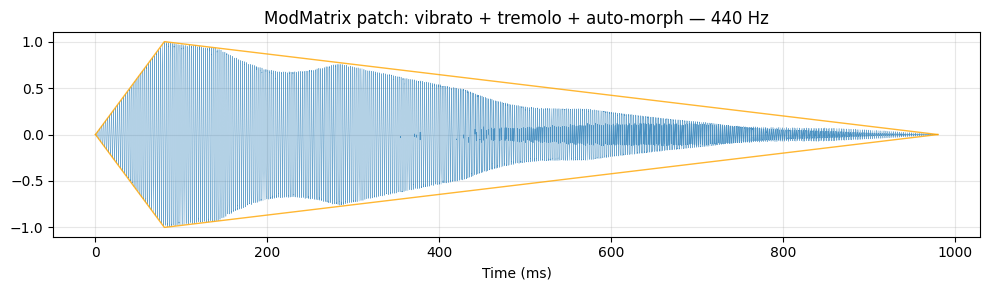

In [21]:
# ── Integration with ModMatrix ───────────────────────────────────────────────
# Signal chain:
#   LFO (vibrato) ──► source 0 ─┐
#   LFO (tremolo) ──► source 1 ─┤  ModMatrix  ──► freq_param, amp_param
#                                │              ──► morph_param
#   LFO (morph)  ──► source 2 ──┘
#
#   WavetableOsc4(freq_param, amp_param, morph_param) ──► AD envelope ──► out

def render_note_modmatrix(
        freq_hz      = 440.0,
        morph_start  = 0.0,
        attack_ms    = 80,
        decay_ms     = 800,
        vib_rate     = 5.0,
        vib_depth    = 0.03,
        trem_rate    = 4.0,
        trem_depth   = 0.25,
        morph_rate   = 0.2,
        morph_depth  = 0.3,
        noise_mix    = 0.02,
        sr           = SR):

    n        = int(sr * (attack_ms + decay_ms) / 1000)
    attack_n = int(sr * attack_ms / 1000)

    # AD envelope
    env = np.empty(n)
    env[:attack_n] = np.linspace(0, 1, attack_n)
    env[attack_n:] = np.linspace(1, 0, n - attack_n)

    # Vibrato fades in after 20% of note
    vib_scale = np.zeros(n)
    fade_start = int(n * 0.2)
    fade_len   = min(int(n * 0.15), n - fade_start)
    if fade_len > 0:
        vib_scale[fade_start:fade_start + fade_len] = np.linspace(0, 1, fade_len)
        vib_scale[fade_start + fade_len:]            = 1.0

    # Parameters
    p_freq  = cp.ModulatableParameter(20.0, 2000.0, 0.0)
    p_freq.set_range(20.0, 2000.0, cp.ParameterScale.Logarithmic)
    p_amp   = cp.ModulatableParameter(0.0, 1.0, 1.0)
    p_morph = cp.ModulatableParameter(0.0, 1.0, morph_start / 3.0)

    # Settle all parameters
    for p in [p_freq, p_amp, p_morph]:
        p.skip(2000)

    # ModMatrix
    mat    = cp.ModMatrix()
    d_freq = mat.register_parameter(p_freq)
    d_amp  = mat.register_parameter(p_amp)
    d_morph = mat.register_parameter(p_morph)

    mat.add_routing(cp.ModulationRouting(0, d_freq,  vib_depth))   # source 0 → freq
    mat.add_routing(cp.ModulationRouting(1, d_amp,   trem_depth))  # source 1 → amp
    mat.add_routing(cp.ModulationRouting(2, d_morph, morph_depth)) # source 2 → morph
    mat.process()

    # LFOs
    lfo_vib   = cp.lfo.LFO(float(sr), vib_rate)
    lfo_trem  = cp.lfo.LFO(float(sr), trem_rate,
                              cp.lfo.LfoShape.Sine,
                              cp.lfo.LfoOutputMode.Bipolar)
    lfo_morph = cp.lfo.LFO(float(sr), morph_rate,
                              cp.lfo.LfoShape.Triangle,
                              cp.lfo.LfoOutputMode.Unipolar)

    # Oscillator + noise
    osc   = cp.wavetable.WavetableOscillator4(bank4, float(sr), freq_hz)
    noise = cp.noise.NoiseOscillatorWhite(float(sr))

    buf = np.empty(n, dtype=np.float32)
    for i in range(n):
        # Push sources
        mat.set_source_value(0, lfo_vib.render_sample()   * vib_scale[i])
        mat.set_source_value(1, lfo_trem.render_sample())
        mat.set_source_value(2, lfo_morph.render_sample() * 2.0 - 1.0)  # centre bipolar
        mat.process()

        p_freq.process()
        p_amp.process()
        p_morph.process()

        # Apply to oscillator
        osc.frequency.clear_modulation()
        osc.frequency.add_modulation(p_freq.value_normalised()
                                     - p_freq.get_base_normalised())

        osc.amplitude.clear_modulation()
        osc.amplitude.add_modulation(p_amp.value_normalised()
                                     - p_amp.get_base_normalised())

        morph_norm = p_morph.value_normalised()
        osc.set_morph_position(morph_norm * 3.0)

        sig    = osc.render_sample()
        nz     = noise.render_sample()
        buf[i] = ((1.0 - noise_mix) * sig + noise_mix * nz) * env[i]

    return buf, env


buf_mm, env_mm = render_note_modmatrix(
    freq_hz=440, morph_start=0.5,
    attack_ms=80, decay_ms=900,
    vib_rate=5.0,  vib_depth=0.025,
    trem_rate=3.5, trem_depth=0.2,
    morph_rate=0.3, morph_depth=0.25,
    noise_mix=0.015,
)

t_ms = np.arange(len(buf_mm)) / SR * 1000
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t_ms, buf_mm, linewidth=0.3, alpha=0.8)
ax.plot(t_ms, env_mm,  color='orange', linewidth=1.0, alpha=0.8)
ax.plot(t_ms, -env_mm, color='orange', linewidth=1.0, alpha=0.8)
ax.set_xlabel('Time (ms)')
ax.set_title('ModMatrix patch: vibrato + tremolo + auto-morph — 440 Hz')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
display(Audio(buf_mm * 0.5, rate=SR, normalize=False))

## 6. Interactive synth patch

In [23]:
# ── Interactive ModMatrix patchbay ────────────────────────────────────────────
# Sources: LFO Vibrato (sine), LFO Tremolo (sine), LFO Morph (triangle)
# Destinations: Frequency, Amplitude, Morph position
#
# UI: 3×3 grid — each cell has an Enable checkbox, Depth slider, Curve dropdown.
# Any change re-renders the note immediately.

import itertools

SR = 44100

N_SOURCES = 3
N_DESTS   = 3

SOURCE_LABELS = ['Vib LFO', 'Trem LFO', 'Morph LFO']
DEST_LABELS   = ['Frequency', 'Amplitude', 'Morph pos']

# Per-source LFO config: (shape, output_mode, default_rate)
SOURCE_LFO_CONFIG = [
    (lfo_mod.LfoShape.Sine,     lfo_mod.LfoOutputMode.Bipolar,  5.0),
    (lfo_mod.LfoShape.Sine,     lfo_mod.LfoOutputMode.Bipolar,  3.5),
    (lfo_mod.LfoShape.Triangle, lfo_mod.LfoOutputMode.Unipolar, 0.3),
]

curve_map = {
    'Linear':      cp.ModulationCurve.Linear,
    'Exponential': cp.ModulationCurve.Exponential,
    'Logarithmic': cp.ModulationCurve.Logarithmic,
    'SCurve':      cp.ModulationCurve.SCurve,
}

# ── Per-cell widgets ──────────────────────────────────────────────────────────
# cell_enabled[src][dst], cell_depth[src][dst], cell_curve[src][dst]
cell_enabled = [[widgets.Checkbox(value=False, indent=False,
                                   layout=widgets.Layout(width='60px'))
                 for _ in range(N_DESTS)] for _ in range(N_SOURCES)]

cell_depth   = [[widgets.FloatSlider(value=0.2, min=0.0, max=1.0, step=0.01,
                                      continuous_update=False,
                                      layout=widgets.Layout(width='160px'),
                                      style={'description_width': '0px'})
                 for _ in range(N_DESTS)] for _ in range(N_SOURCES)]

cell_curve   = [[widgets.Dropdown(options=list(curve_map), value='Linear',
                                   layout=widgets.Layout(width='120px'))
                 for _ in range(N_DESTS)] for _ in range(N_SOURCES)]

# ── Per-source rate sliders ───────────────────────────────────────────────────
source_rate  = [widgets.FloatSlider(value=cfg[2], min=0.05, max=20.0, step=0.05,
                                     description=f'{lbl} rate',
                                     continuous_update=False,
                                     layout=widgets.Layout(width='300px'))
                for lbl, cfg in zip(SOURCE_LABELS, SOURCE_LFO_CONFIG)]

# ── Note / envelope widgets ───────────────────────────────────────────────────
w_pb_note  = widgets.FloatLogSlider(value=440, base=2,
                                     min=np.log2(65.4), max=np.log2(1046.5),
                                     step=0.01, description='Freq (Hz)',
                                     continuous_update=False)
w_pb_morph = widgets.FloatSlider(value=0.5, min=0, max=3, step=0.05,
                                  description='Morph start',
                                  continuous_update=False)
w_pb_atk   = widgets.IntSlider(value=80,  min=5,   max=500,  description='Attack (ms)',
                                 continuous_update=False)
w_pb_dec   = widgets.IntSlider(value=900, min=100, max=4000, description='Decay (ms)',
                                 continuous_update=False)
w_pb_noise = widgets.FloatSlider(value=0.015, min=0, max=0.3, step=0.005,
                                  description='Noise mix',
                                  continuous_update=False)

out_pb = widgets.Output()

# ── Render function ───────────────────────────────────────────────────────────
def render_patchbay(_):
    freq        = float(w_pb_note.value)
    attack_ms   = w_pb_atk.value
    decay_ms    = w_pb_dec.value
    morph_start = w_pb_morph.value
    noise_mix   = w_pb_noise.value

    n        = int(SR * (attack_ms + decay_ms) / 1000)
    attack_n = int(SR * attack_ms / 1000)

    env = np.empty(n)
    env[:attack_n] = np.linspace(0, 1, attack_n)
    env[attack_n:] = np.linspace(1, 0, n - attack_n)

    vib_scale = np.zeros(n)
    fade_start = int(n * 0.2)
    fade_len   = min(int(n * 0.15), n - fade_start)
    if fade_len > 0:
        vib_scale[fade_start:fade_start + fade_len] = np.linspace(0, 1, fade_len)
        vib_scale[fade_start + fade_len:]            = 1.0
    # Only apply vib_scale to source 0; others are constant
    source_scales = [vib_scale, np.ones(n), np.ones(n)]

    # Parameters
    p_freq  = cp.ModulatableParameter(20.0, 2000.0, 0.0)
    p_freq.set_range(20.0, 2000.0, cp.ParameterScale.Logarithmic)
    p_amp   = cp.ModulatableParameter(0.0, 1.0, 1.0)
    p_morph = cp.ModulatableParameter(0.0, 1.0, morph_start / 3.0)
    params  = [p_freq, p_amp, p_morph]
    for p in params:
        p.skip(2000)

    # Build ModMatrix from current cell state
    mat    = cp.ModMatrix()
    d_ids  = [mat.register_parameter(p) for p in params]

    active_routings = []  # (src, dst) pairs that are enabled
    for src in range(N_SOURCES):
        for dst in range(N_DESTS):
            if cell_enabled[src][dst].value:
                r       = cp.ModulationRouting(src, d_ids[dst],
                                                cell_depth[src][dst].value)
                r.curve = curve_map[cell_curve[src][dst].value]
                mat.add_routing(r)
                active_routings.append((src, dst))

    mat.process()

    # LFOs
    lfos = []
    for src, (shape, mode, _) in enumerate(SOURCE_LFO_CONFIG):
        lfo = lfo_mod.LFO(float(SR), source_rate[src].value)
        lfo.set_shape(shape)
        lfo.set_output_mode(mode)
        lfo.reset_phase()
        lfos.append(lfo)

    osc   = cp.wavetable.WavetableOscillator4(bank4, float(SR), freq)
    noise = cp.noise.NoiseOscillatorWhite(float(SR))

    buf        = np.empty(n, dtype=np.float32)
    src_trace  = np.empty((N_SOURCES, n))  # record source signals for plot

    for i in range(n):
        for src, lfo in enumerate(lfos):
            val = lfo.render_sample() * source_scales[src][i]
            mat.set_source_value(src, float(val))
            src_trace[src, i] = val

        mat.process()
        for p in params:
            p.process()

        osc.frequency.clear_modulation()
        osc.frequency.add_modulation(
            p_freq.value_normalised() - p_freq.get_base_normalised())

        osc.amplitude.clear_modulation()
        osc.amplitude.add_modulation(
            p_amp.value_normalised() - p_amp.get_base_normalised())

        osc.set_morph_position(p_morph.value_normalised() * 3.0)

        sig    = osc.render_sample()
        nz     = noise.render_sample()
        buf[i] = ((1.0 - noise_mix) * sig + noise_mix * nz) * env[i]

    note_label = freq_to_note(freq)
    t_ms       = np.arange(n) / SR * 1000

    with out_pb:
        out_pb.clear_output(wait=True)

        n_active = len(active_routings)
        n_rows   = 2 + (1 if n_active > 0 else 0)
        fig, axes = plt.subplots(n_rows, 1,
                                  figsize=(10, 2.5 * n_rows),
                                  sharex=True)
        if n_rows == 1:
            axes = [axes]

        # Audio + envelope
        axes[0].plot(t_ms, buf, linewidth=0.3, alpha=0.8)
        axes[0].plot(t_ms,  env, color='orange', linewidth=0.9, alpha=0.7)
        axes[0].plot(t_ms, -env, color='orange', linewidth=0.9, alpha=0.7)
        axes[0].set_ylabel('Amplitude')
        axes[0].set_title(f'{note_label}  ({freq:.1f} Hz)')
        axes[0].grid(True, alpha=0.3)

        # Source signals
        colors = ['steelblue', 'darkorange', 'seagreen']
        for src in range(N_SOURCES):
            axes[1].plot(t_ms, src_trace[src],
                         linewidth=0.7, alpha=0.8,
                         color=colors[src], label=SOURCE_LABELS[src])
        axes[1].set_ylabel('Source value')
        axes[1].set_title('LFO sources')
        axes[1].legend(fontsize=8, loc='upper right')
        axes[1].grid(True, alpha=0.3)

        # Active routing traces: modulated parameter values
        if n_active > 0:
            # Re-run a lightweight param capture pass using recorded src_trace
            param_traces = {d: np.empty(n) for d in range(N_DESTS)}
            p2  = cp.ModulatableParameter(20.0, 2000.0, 0.0)
            p2.set_range(20.0, 2000.0, cp.ParameterScale.Logarithmic)
            pa2 = cp.ModulatableParameter(0.0, 1.0, 1.0)
            pm2 = cp.ModulatableParameter(0.0, 1.0, morph_start / 3.0)
            pp  = [p2, pa2, pm2]
            for p in pp: p.skip(2000)
            mat2   = cp.ModMatrix()
            dd     = [mat2.register_parameter(p) for p in pp]
            for src in range(N_SOURCES):
                for dst in range(N_DESTS):
                    if cell_enabled[src][dst].value:
                        r2       = cp.ModulationRouting(src, dd[dst],
                                                         cell_depth[src][dst].value)
                        r2.curve = curve_map[cell_curve[src][dst].value]
                        mat2.add_routing(r2)
            mat2.process()
            for i in range(n):
                for src in range(N_SOURCES):
                    mat2.set_source_value(src, float(src_trace[src, i]))
                mat2.process()
                for p in pp: p.process()
                param_traces[0][i] = pp[0].value_normalised()
                param_traces[1][i] = pp[1].value_normalised()
                param_traces[2][i] = pp[2].value_normalised()

            dest_colors = ['crimson', 'mediumpurple', 'teal']
            for dst in range(N_DESTS):
                if any(cell_enabled[s][dst].value for s in range(N_SOURCES)):
                    axes[2].plot(t_ms, param_traces[dst],
                                 linewidth=0.7, alpha=0.9,
                                 color=dest_colors[dst],
                                 label=DEST_LABELS[dst])
            axes[2].set_ylabel('Param (norm)')
            axes[2].set_title('Modulated destination values')
            axes[2].legend(fontsize=8, loc='upper right')
            axes[2].grid(True, alpha=0.3)

        axes[-1].set_xlabel('Time (ms)')
        plt.tight_layout()
        plt.show()

        fade       = np.ones(n)
        fl         = min(2000, n // 8)
        fade[-fl:] = np.linspace(1, 0, fl)
        display(Audio(buf * fade * 0.5, rate=SR, normalize=False))

# ── Wire all widgets ──────────────────────────────────────────────────────────
all_cell_widgets = list(itertools.chain.from_iterable(
    [cell_enabled[s][d], cell_depth[s][d], cell_curve[s][d]]
    for s in range(N_SOURCES) for d in range(N_DESTS)
))
note_widgets = [w_pb_note, w_pb_morph, w_pb_atk, w_pb_dec, w_pb_noise]

for w in all_cell_widgets + note_widgets + source_rate:
    w.observe(render_patchbay, names='value')

# ── Layout ────────────────────────────────────────────────────────────────────
header_row = widgets.HBox(
    [widgets.Label('', layout=widgets.Layout(width='80px'))] +
    [widgets.Label(lbl, layout=widgets.Layout(width='350px'))
     for lbl in DEST_LABELS]
)

grid_rows = []
for src in range(N_SOURCES):
    row_label = widgets.Label(SOURCE_LABELS[src],
                               layout=widgets.Layout(width='80px'))
    cells = []
    for dst in range(N_DESTS):
        cell = widgets.VBox([
            cell_enabled[src][dst],
            cell_depth[src][dst],
            cell_curve[src][dst],
        ], layout=widgets.Layout(width='350px', border='1px solid #ddd',
                                  padding='4px'))
        cells.append(cell)
    grid_rows.append(widgets.HBox([row_label] + cells))

matrix_box = widgets.VBox([header_row] + grid_rows,
                            layout=widgets.Layout(border='2px solid #aaa',
                                                   padding='6px'))

rate_box = widgets.HBox(source_rate)

note_box = widgets.HBox([w_pb_note, w_pb_morph])
env_box  = widgets.HBox([w_pb_atk, w_pb_dec, w_pb_noise])

render_patchbay(None)
display(widgets.VBox([
    widgets.HTML('<b>Modulation Matrix</b> — enable a cell to route a source to a destination'),
    matrix_box,
    widgets.HTML('<b>LFO Rates</b>'),
    rate_box,
    widgets.HTML('<b>Note / Envelope</b>'),
    note_box,
    env_box,
    out_pb,
]))